In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [19]:
df = pd.read_csv('../data/preprocessed_train.csv')

X = df.drop(columns=["TARGET"])
y = df["TARGET"]

cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(246008, 228)
(61503, 228)
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


In [14]:
def ks_statistic(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    return max(tpr - fpr)


def best_f1_score(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
    return f1_scores.max()


def evaluate_model(y_true, y_prob):
    auroc = roc_auc_score(y_true, y_prob)
    gini = 2 * auroc - 1
    ks = ks_statistic(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    f1 = best_f1_score(y_true, y_prob)

    return auroc, gini, ks, auprc, f1

# 1. Logistic Regression (C=0.1, max_iter=1000)

In [21]:
lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced", random_state=42))
])

lr_pipeline.fit(X_train, y_train)

lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

lr_auroc, lr_gini, lr_ks, lr_auprc, lr_f1 = evaluate_model(y_test, lr_prob)

In [22]:
print(f"AUROC: {lr_auroc:.4f}")
print(f"Gini: {lr_gini:.4f}")
print(f"KS: {lr_ks:.4f}")
print(f"AUPRC: {lr_auprc:.4f}")
print(f"Best F1: {lr_f1:.4f}")

AUROC: 0.7540
Gini: 0.5080
KS: 0.3777
AUPRC: 0.2413
Best F1: 0.3086


# 2. Random Forest

In [23]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

rf_auroc, rf_gini, rf_ks, rf_auprc, rf_f1 = evaluate_model(y_test, rf_prob)

print(f"AUROC: {rf_auroc:.4f}")
print(f"Gini: {rf_gini:.4f}")
print(f"KS: {rf_ks:.4f}")
print(f"AUPRC: {rf_auprc:.4f}")
print(f"Best F1: {rf_f1:.4f}")

AUROC: 0.7464
Gini: 0.4929
KS: 0.3697
AUPRC: 0.2266
Best F1: 0.2970


# 3. Gradient Boosting

In [24]:
gb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

gb_prob = gb_pipeline.predict_proba(X_test)[:, 1]

gb_auroc, gb_gini, gb_ks, gb_auprc, gb_f1 = evaluate_model(y_test, gb_prob)

print(f"AUROC: {gb_auroc:.4f}")
print(f"Gini: {gb_gini:.4f}")
print(f"KS: {gb_ks:.4f}")
print(f"AUPRC: {gb_auprc:.4f}")
print(f"Best F1: {gb_f1:.4f}")

AUROC: 0.7604
Gini: 0.5209
KS: 0.3848
AUPRC: 0.2518
Best F1: 0.3153


# 4. Model Comparison Table

In [25]:
comparison_table = pd.DataFrame(
{
    "Model": ["Logistic Regression","Random Forest","Gradient Boosting"],
    "AUROC": [lr_auroc,rf_auroc,gb_auroc],
    "Gini": [lr_gini,rf_gini,gb_gini],
    "KS": [lr_ks,rf_ks,gb_ks],
    "AUPRC": [lr_auprc,rf_auprc,gb_auprc],
    "Best F1": [lr_f1,rf_f1,gb_f1]
})

comparison_table = comparison_table.sort_values("AUROC", ascending=False)
comparison_table

,Model,AUROC,Gini,KS,AUPRC,Best F1
2,Gradient Boosting,0.760427,0.520853,0.384774,0.251793,0.315299
0,Logistic Regression,0.753993,0.507985,0.377705,0.241301,0.308583
1,Random Forest,0.746444,0.492887,0.369655,0.226641,0.297030


# 5. ROC and Precision-Recall curves

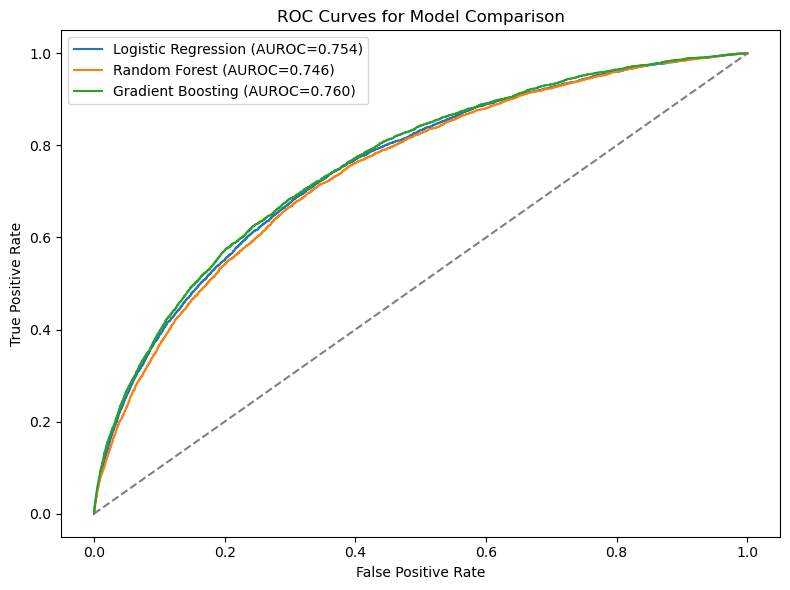

In [26]:
plt.figure(figsize=(8, 6))

model_probs = {
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
    "Gradient Boosting": gb_prob
}

for name, prob in model_probs.items():
    fpr, tpr, thresholds = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUROC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title("ROC Curves for Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

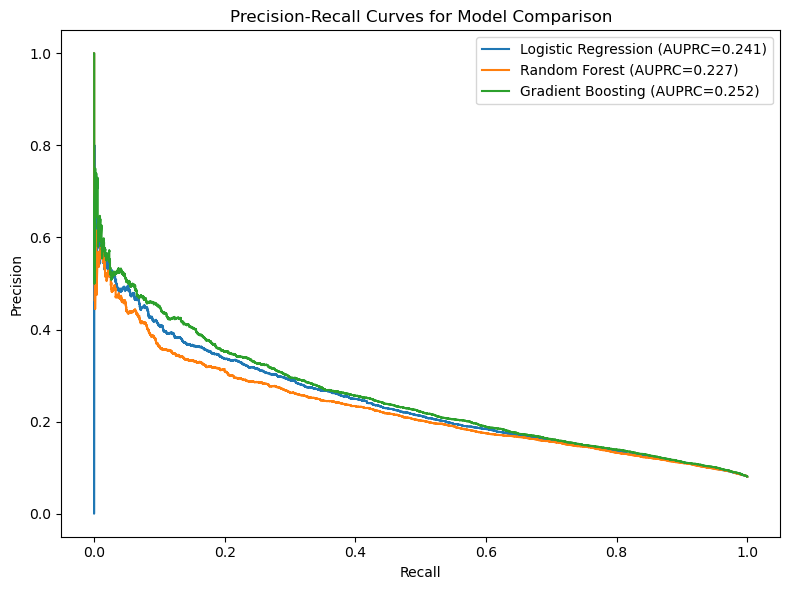

In [27]:
plt.figure(figsize=(8, 6))

for name, prob in model_probs.items():
    precision, recall, thresholds = precision_recall_curve(y_test, prob)
    auprc = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} (AUPRC={auprc:.3f})")

plt.title("Precision-Recall Curves for Model Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

# 6. Cross-Validation

In [31]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_scores = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1
)

print("Logistic Regression CV Results")
print(f"Mean AUROC: {lr_scores.mean():.4f}")
print(f"Std AUROC:  {lr_scores.std():.4f}")

Logistic Regression CV Results
Mean AUROC: 0.7508
Std AUROC:  0.0028


In [32]:
rf_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1
)

print("Random Forest CV Results")
print(f"Mean AUROC: {rf_scores.mean():.4f}")
print(f"Std AUROC:  {rf_scores.std():.4f}")

Random Forest CV Results
Mean AUROC: 0.7424
Std AUROC:  0.0023


In [33]:
gb_scores = cross_val_score(
    gb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1
)

print("Gradient Boosting CV Results")
print(f"Mean AUROC: {gb_scores.mean():.4f}")
print(f"Std AUROC:  {gb_scores.std():.4f}")

Gradient Boosting CV Results
Mean AUROC: 0.7572
Std AUROC:  0.0011


In [36]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean AUROC": [
        lr_scores.mean(),
        rf_scores.mean(),
        gb_scores.mean()
    ],
    "Std AUROC": [
        lr_scores.std(),
        rf_scores.std(),
        gb_scores.std()
    ]
})

cv_results

,Model,Mean AUROC,Std AUROC
0,Logistic Regression,0.750759,0.002768
1,Random Forest,0.742430,0.002276
2,Gradient Boosting,0.757176,0.001109


# 7. Hyperparameter Tuning for Gradient Boosting

In [43]:
param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=param_dist,
    n_iter=8,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.05}
0.7639559249776291


In [45]:
best_model = search.best_estimator_

joblib.dump(best_model, "../models/best_model.pkl")

['../models/best_model.pkl']